Section 1 – Import Libraries

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Section 2 – Set Random Seed

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cpu


Section 3 – Load Processed Data

In [4]:
X_train = np.load("../Processed_Data/X_train.npy")
X_val = np.load("../Processed_Data/X_val.npy")
X_test = np.load("../Processed_Data/X_test.npy")

y_train = np.load("../Processed_Data/y_train.npy")
y_val = np.load("../Processed_Data/y_val.npy")
y_test = np.load("../Processed_Data/y_test.npy")

Section 4 – Verify Shapes

In [5]:
print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)

Training: (583, 14, 512) (583,)
Validation: (184, 14, 512) (184,)
Testing: (222, 14, 512) (222,)


Section 5 – Convert to PyTorch Tensors

In [6]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

Section 6 – Add Channel Dimension

In [7]:
X_train = X_train.unsqueeze(1)
X_val = X_val.unsqueeze(1)
X_test = X_test.unsqueeze(1)

print(X_train.shape)

torch.Size([583, 1, 14, 512])


Section 7 – Create DataLoaders

In [8]:
batch_size = 32

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

Section 8 – Verify DataLoader

In [9]:
for X, y in train_loader:
    print("Batch X:", X.shape)
    print("Batch y:", y.shape)
    break

Batch X: torch.Size([32, 1, 14, 512])
Batch y: torch.Size([32])


Step 9 — Build EEGNet

In [10]:
# EEGNet Architecture

import torch
import torch.nn as nn


class EEGNet(nn.Module):

    def __init__(self, num_classes=2):
        super().__init__()

        # Block 1
        self.block1 = nn.Sequential(

            nn.Conv2d(
                in_channels=1,
                out_channels=8,
                kernel_size=(1,64),
                padding=(0,32),
                bias=False
            ),

            nn.BatchNorm2d(8),

            nn.Conv2d(
                in_channels=8,
                out_channels=16,
                kernel_size=(14,1),
                groups=8,
                bias=False
            ),

            nn.BatchNorm2d(16),

            nn.ELU(),

            nn.AvgPool2d((1,4)),

            nn.Dropout(0.25)
        )

        # Block 2
        self.block2 = nn.Sequential(

            nn.Conv2d(
                16,
                16,
                kernel_size=(1,16),
                padding=(0,8),
                groups=16,
                bias=False
            ),

            nn.Conv2d(
                16,
                16,
                kernel_size=(1,1),
                bias=False
            ),

            nn.BatchNorm2d(16),

            nn.ELU(),

            nn.AvgPool2d((1,8)),

            nn.Dropout(0.25)
        )

        self.classifier = nn.Linear(16*1*16, num_classes)

    def forward(self, x):

        x = self.block1(x)

        x = self.block2(x)

        x = x.view(x.size(0), -1)

        x = self.classifier(x)

        return x


Step 10 — Create the Model

In [11]:
model = EEGNet(num_classes=2).to(device)

print(model)

EEGNet(
  (block1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(1, 64), stride=(1, 1), padding=(0, 32), bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Conv2d(8, 16, kernel_size=(14, 1), stride=(1, 1), groups=8, bias=False)
    (3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ELU(alpha=1.0)
    (5): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (6): Dropout(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=16, bias=False)
    (1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ELU(alpha=1.0)
    (4): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (5): Dropout(p=0.25, inplace=False)
  )
  (classifier): Linear(in_features=256, out_features=2, bias=True)
)


Step 11 — Check Input Shape

In [12]:
sample = torch.randn(32,1,14,512).to(device)

output = model(sample)

print(output.shape)

torch.Size([32, 2])


Step 12 — Loss Function and Optimizer

In [13]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Step 13 — Define Loss and Optimizer

In [14]:
# Step 13: Define loss function and optimizer
#
# CrossEntropyLoss is used for binary classification.
# Adam optimizer is chosen because it converges faster
# and is widely used for deep learning models.

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

Step 14 — Training Parameters

In [15]:
# Step 14: Define training hyperparameters
#
# Set the number of epochs and initialize variables to
# store training and validation loss and accuracy.

EPOCHS = 100

best_val_acc = 0

train_losses = []
val_losses = []

train_accs = []
val_accs = []

Step 15 — Accuracy Function

In [16]:
# Step 15: Accuracy function
#
# Computes classification accuracy by comparing predicted
# class labels with the ground truth labels.

def accuracy(outputs, labels):

    predictions = torch.argmax(outputs, dim=1)

    correct = (predictions == labels).sum().item()

    return correct / len(labels)

Step 16: Training Loop

In [17]:
# Step 16: Train the EEGNet model
#
# The model is trained using the training dataset and
# evaluated on the validation dataset after each epoch.
# The model with the highest validation accuracy is saved
# to prevent overfitting and to use the best-performing
# version for final testing.

In [18]:
best_val_acc = 0

train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(EPOCHS):

    # Training
    model.train()

    running_loss = 0
    running_acc = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        running_acc += accuracy(outputs, y_batch)

    train_loss = running_loss / len(train_loader)
    train_acc = running_acc / len(train_loader)

    
    # Validation
    
    model.eval()

    running_loss = 0
    running_acc = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            running_loss += loss.item()
            running_acc += accuracy(outputs, y_batch)

    val_loss = running_loss / len(val_loader)
    val_acc = running_acc / len(val_loader)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    
    # Save Best Model
    
    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(model.state_dict(), "../models/eegnet_best.pth")

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/100] | Train Loss: 0.7002 | Train Acc: 0.5883 | Val Loss: 0.6402 | Val Acc: 0.7917
Epoch [2/100] | Train Loss: 0.5904 | Train Acc: 0.6807 | Val Loss: 0.8164 | Val Acc: 0.4688
Epoch [3/100] | Train Loss: 0.5488 | Train Acc: 0.7192 | Val Loss: 1.2584 | Val Acc: 0.4688
Epoch [4/100] | Train Loss: 0.5294 | Train Acc: 0.6938 | Val Loss: 1.5088 | Val Acc: 0.4062
Epoch [5/100] | Train Loss: 0.5103 | Train Acc: 0.7253 | Val Loss: 1.5541 | Val Acc: 0.5104
Epoch [6/100] | Train Loss: 0.4949 | Train Acc: 0.7270 | Val Loss: 1.4688 | Val Acc: 0.5677
Epoch [7/100] | Train Loss: 0.4852 | Train Acc: 0.7451 | Val Loss: 1.6329 | Val Acc: 0.4583
Epoch [8/100] | Train Loss: 0.5019 | Train Acc: 0.7455 | Val Loss: 1.8374 | Val Acc: 0.4062
Epoch [9/100] | Train Loss: 0.4846 | Train Acc: 0.7422 | Val Loss: 1.7727 | Val Acc: 0.4062
Epoch [10/100] | Train Loss: 0.4838 | Train Acc: 0.7531 | Val Loss: 1.7500 | Val Acc: 0.4115
Epoch [11/100] | Train Loss: 0.4951 | Train Acc: 0.7183 | Val Loss: 1.9038 | Va

Step 17: Check the Best Validation Accuracy

In [19]:
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

Best Validation Accuracy: 0.7917


Evaluate on the Test Set

In [21]:
# Test Best EEGNet Model
model = EEGNet(num_classes=2).to(device)

model.load_state_dict(torch.load("../models/eegnet_best.pth"))

model.eval()


EEGNet(
  (block1): Sequential(
    (0): Conv2d(1, 8, kernel_size=(1, 64), stride=(1, 1), padding=(0, 32), bias=False)
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): Conv2d(8, 16, kernel_size=(14, 1), stride=(1, 1), groups=8, bias=False)
    (3): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): ELU(alpha=1.0)
    (5): AvgPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0)
    (6): Dropout(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(16, 16, kernel_size=(1, 16), stride=(1, 1), padding=(0, 8), groups=16, bias=False)
    (1): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ELU(alpha=1.0)
    (4): AvgPool2d(kernel_size=(1, 8), stride=(1, 8), padding=0)
    (5): Dropout(p=0.25, inplace=False)
  )
  (classifier): Linear(in_features=256, out_features=2, bias=True)
)

Step 18: Evaluate on the Test Set

In [22]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

Run inference on the test set

In [23]:
model.eval()

y_true = []
y_pred = []
y_prob = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        probabilities = torch.softmax(outputs, dim=1)

        predictions = torch.argmax(outputs, dim=1)

        y_true.extend(y_batch.numpy())
        y_pred.extend(predictions.cpu().numpy())
        y_prob.extend(probabilities[:, 1].cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

Step 19: Compute Evaluation Metrics

In [24]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc = roc_auc_score(y_true, y_prob)

print("Test Accuracy :", round(accuracy,4))
print("Precision     :", round(precision,4))
print("Recall        :", round(recall,4))
print("F1-score      :", round(f1,4))
print("ROC-AUC       :", round(auc,4))

Test Accuracy : 0.9414
Precision     : 0.9804
Recall        : 0.9009
F1-score      : 0.939
ROC-AUC       : 0.9622


Step 20: Classification Report

In [25]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       111
           1       0.98      0.90      0.94       111

    accuracy                           0.94       222
   macro avg       0.94      0.94      0.94       222
weighted avg       0.94      0.94      0.94       222



Step 21: Confusion Matrix

In [26]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[109   2]
 [ 11 100]]


Visualize the confusion matrix

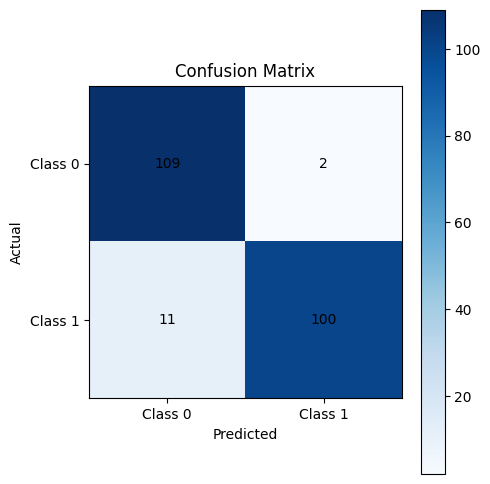

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))

plt.imshow(cm, interpolation="nearest", cmap="Blues")

plt.title("Confusion Matrix")

plt.colorbar()

classes = ["Class 0", "Class 1"]

tick_marks = np.arange(len(classes))

plt.xticks(tick_marks, classes)
plt.yticks(tick_marks, classes)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color="black"
        )

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.show()

Step 22: Plot Training History

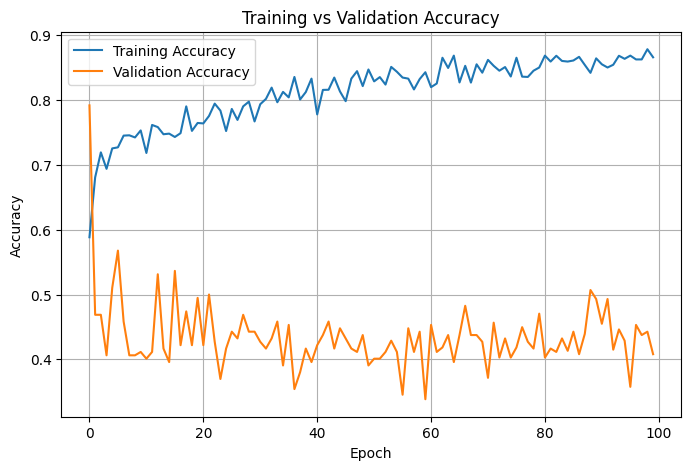

In [28]:
plt.figure(figsize=(8,5))

plt.plot(train_accs, label="Training Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

Loss

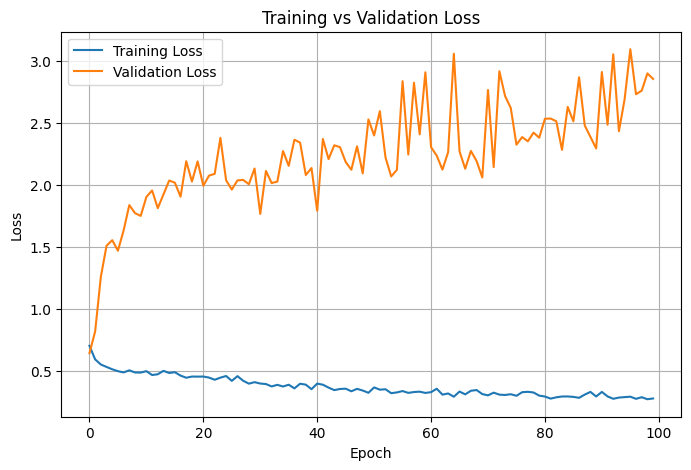

In [29]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

Step 18: Evaluate the best saved EEGNet model on the unseen test dataset.

The evaluation includes:
- Test Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Classification Report
- Confusion Matrix

Training and validation curves are also plotted to analyze the learning behavior and identify overfitting or underfitting.